#Yahoo Finance with GRU

Here, We'll do a stock market forecasting With a LSTM and GRU model, based on it history.

##1) Install Packages

In [ ]:
!pip install yfinance matplotlib scikit-learn torch --quiet

In [ ]:
!pip install optuna

##2) Import Frameworks and Liberies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

##3) Data modeling

Here, We'll create a temporal window for the data.

In [ ]:
# Pure pandas function to calculate indicators
def add_indicators(df, col='Close', window=14):
    df[f'SMA_{window}'] = df[col].rolling(window=window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100 / (1 + rs))
    return df

Then, We selected 7 market actions as data and, collect their data.

In [ ]:
# Data collection and preparation with indicators
# 'PETR4.SA', 'VALE3.SA', 'ITUB4.SA'
tickers = ['^DJI', '^IXIC', 'ALI=F', 'HG=F', 'MGC=F', 'G', '^GSPC']
dfs = []

for t in tickers:
    df = yf.download(t, start='2018-07-31', end='2025-07-31')
    df = df[['Close']].rename(columns={'Close': f'{t}_Close'})
    df = add_indicators(df, col=f'{t}_Close', window=14)
    dfs.append(df)

data = pd.concat(dfs, axis=1).dropna()
data.head()

/tmp/ipython-input-367440607.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start='2018-07-31', end='2025-07-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-367440607.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start='2018-07-31', end='2025-07-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-367440607.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start='2018-07-31', end='2025-07-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-367440607.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, start='2018-07-31', end='2025-07-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-367440607.py:

Price,^DJI_Close,SMA_14,EMA_14,RSI_14,^IXIC_Close,SMA_14,EMA_14,RSI_14,ALI=F_Close,SMA_14,...,EMA_14,RSI_14,G_Close,SMA_14,EMA_14,RSI_14,^GSPC_Close,SMA_14,EMA_14,RSI_14
Ticker,^DJI,,,,^IXIC,,,,ALI=F,,...,,,G,,,,^GSPC,,,
Date,,,,,,,,,,,,,,,,,,,,,
2018-08-30,25986.919922,25704.652762,25793.876690,68.658048,8088.359863,7909.091413,7942.225649,72.844745,2318.75,2313.875,...,1200.040573,44.376916,27.899038,27.978595,28.024374,49.211201,2901.129883,2863.857840,2872.973201,69.780144
2018-08-31,25964.820312,25760.161412,25816.669173,72.826187,8109.540039,7929.793562,7964.534235,76.477662,2318.75,2314.250,...,1200.248493,56.397460,28.202793,28.005551,28.048163,56.083131,2901.520020,2869.542847,2876.779443,74.786691
2018-09-04,25952.480469,25806.772879,25834.777346,70.362267,8091.250000,7945.533552,7981.429670,71.418266,2318.75,2314.625,...,1199.415361,50.578703,28.184383,28.054204,28.066326,62.171152,2896.719971,2873.597133,2879.438180,69.264181
2018-09-05,25974.990234,25864.814314,25853.472398,77.315876,7995.169922,7961.322824,7983.261704,71.514181,2318.75,2315.000,...,1198.973309,62.739688,27.963474,28.060779,28.052613,51.736102,2888.600098,2878.613560,2880.659769,76.234565
2018-09-06,25995.869141,25896.038504,25872.458630,69.656655,7922.729980,7969.623535,7975.190807,60.492610,2318.75,2315.375,...,1198.976868,65.281514,28.018703,28.075901,28.048091,54.007041,2878.050049,2881.282139,2880.311807,65.301445


Here We do normalization.

In [ ]:
# Normalizing multivariate data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

Now, a sliding window will be created for prediction.

In [ ]:
def create_multivariate_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # predict the closing price of the first asset
    return np.array(X), np.array(y)

So, We split the atributes and target, train and test.

In [ ]:
seq_len = 30
X, y = create_multivariate_sequences(scaled, seq_len)

#train/test Division
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

We format the data to tensors

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Define the splited into batches and shuffle.

In [ ]:
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

Further, We plot the target history.

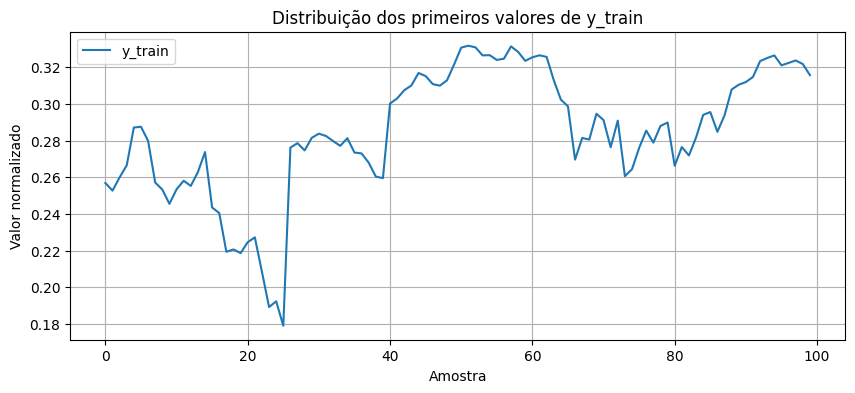

In [ ]:
# Check for significant variance in y_train
plt.figure(figsize=(10, 4))
# Plot the first 100 samples to visually inspect volatility and signal
plt.plot(y_train[:100], label='y_train')
plt.title('Distribution of the first y_train values')
plt.xlabel('Sample')
plt.ylabel('Normalized Value')
plt.grid()
plt.legend()
plt.show()

##4) DL Modeling

Here, We made a hybrid model with LSTM and GRU for prediction.

In [ ]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=128, hidden_gru=64, dropout_rate=0): # Added dropout_rate parameter
        super().__init__()

        # LSTM: learns long-term patterns in the time series
        # input_size: number of features per time step (e.g., Close, RSI, EMA...)
        # hidden_lstm: number of neurons in the LSTM layer
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm, num_layers=1, batch_first=True)

        # GRU: refines the representations learned by the LSTM
        # Takes the LSTM output as its input
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru, num_layers=1, batch_first=True)

        # Dropout layer: helps prevent overfitting by randomly zeroing elements
        self.dropout = nn.Dropout(p=dropout_rate)

        # Final dense layer: transforms the final GRU hidden state into a prediction
        self.fc = nn.Linear(hidden_gru, 1)

    def forward(self, x):

        # LSTM layer output shape: (batch, seq_len, hidden_lstm)
        out_lstm1, _ = self.lstm1(x)

        # GRU layer output shape: (batch, seq_len, hidden_gru)
        out_gru, _ = self.gru(out_lstm1)

        # Apply dropout to the GRU output
        out_gru = self.dropout(out_gru)

        # Extract only the last temporal output (many-to-one architecture)
        final_output = self.fc(out_gru[:, -1, :])  # Shape: (batch, 1)

        return final_output

Then define the loss and optimization model.

In [ ]:
# Automatically detect the number of features
input_size = X_train.shape[2]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM_GRU_Model(input_size=input_size, dropout_rate=0.25).to(device) # Pass dropout_rate to the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

##5) Training and Validation

From here, We will train, validate and store the best model instance.

Epoch  1: Train Loss = 0.018684, Val Loss = 0.002430
Epoch  2: Train Loss = 0.004038, Val Loss = 0.002211
Epoch  3: Train Loss = 0.003013, Val Loss = 0.001871
Epoch  4: Train Loss = 0.002432, Val Loss = 0.001611
Epoch  5: Train Loss = 0.002410, Val Loss = 0.002309
Epoch  6: Train Loss = 0.002167, Val Loss = 0.001009
Epoch  7: Train Loss = 0.002028, Val Loss = 0.001091
Epoch  8: Train Loss = 0.001652, Val Loss = 0.000846
Epoch  9: Train Loss = 0.001898, Val Loss = 0.000821
Epoch 10: Train Loss = 0.001648, Val Loss = 0.000778
Epoch 11: Train Loss = 0.001650, Val Loss = 0.003194
Epoch 12: Train Loss = 0.001586, Val Loss = 0.000875
Epoch 13: Train Loss = 0.001832, Val Loss = 0.001450
Epoch 14: Train Loss = 0.001428, Val Loss = 0.001642
Epoch 15: Train Loss = 0.001665, Val Loss = 0.001700
Epoch 16: Train Loss = 0.001581, Val Loss = 0.001843
Epoch 17: Train Loss = 0.001549, Val Loss = 0.003852
Epoch 18: Train Loss = 0.001565, Val Loss = 0.001245
Epoch 19: Train Loss = 0.001616, Val Loss = 0.

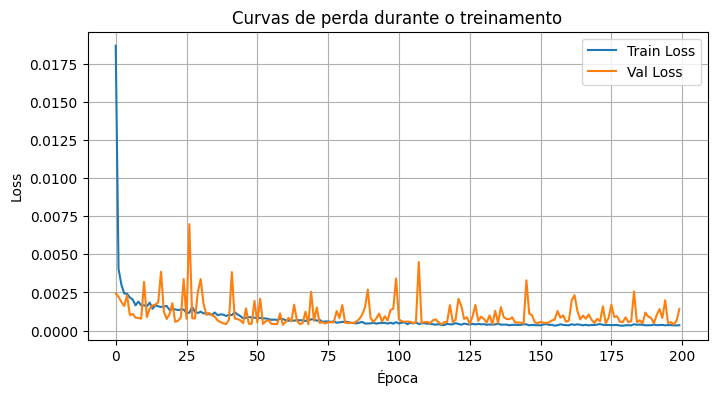

In [ ]:
# Training with validation per epoch + best model saved
from copy import deepcopy
best_val_loss = float('inf')
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(1, 201):
    # Set model to training mode
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass and loss calculation
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)

        # Backward pass and optimization step
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)

    # Validation phase
    model.eval()
    val_batch_losses = []
    with torch.no_grad(): # Disable gradient tracking for efficiency
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())

    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    # Save the best model state based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Deepcopy ensures we save the weights at this specific peak performance
        best_model_state = deepcopy(model.state_dict())

# Restore the best model state after all epochs are completed
model.load_state_dict(best_model_state)

# Loss curve visualization
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss curves during training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

##6) Visualization

Now, We plot the graph comparison between the real and predict values of the stock market history.

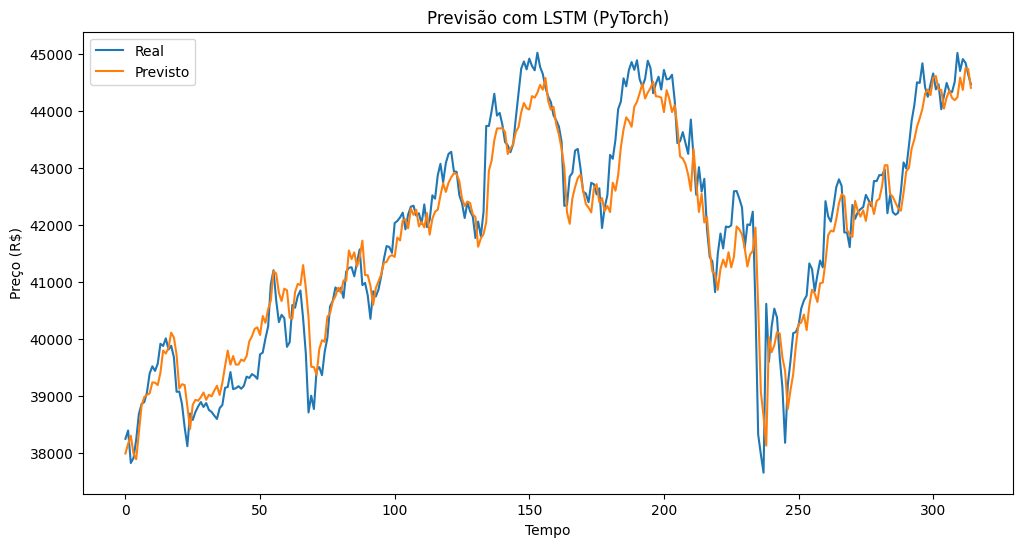

In [ ]:
# Evaluation with correction for multivariate scaler
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

# Reshape to apply inverse_transform only on the target feature
preds = np.array(preds)
# Create placeholder arrays with the same number of features as the original scaler
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))

# Assign predictions and actual values to the target column (index 0)
preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

# Perform inverse transformation and extract the target column
preds_inverse = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse = scaler.inverse_transform(actual_full)[:, 0]

# Visualization
plt.figure(figsize=(12,6))
plt.plot(actual_inverse, label='Actual')
plt.plot(preds_inverse, label='Predicted')
plt.legend()
plt.title('Prediction with LSTM (PyTorch)')
plt.xlabel('Time')
plt.ylabel('Price (R$)')
plt.show()

At this point, We plot the prediction without de inverse transformation.

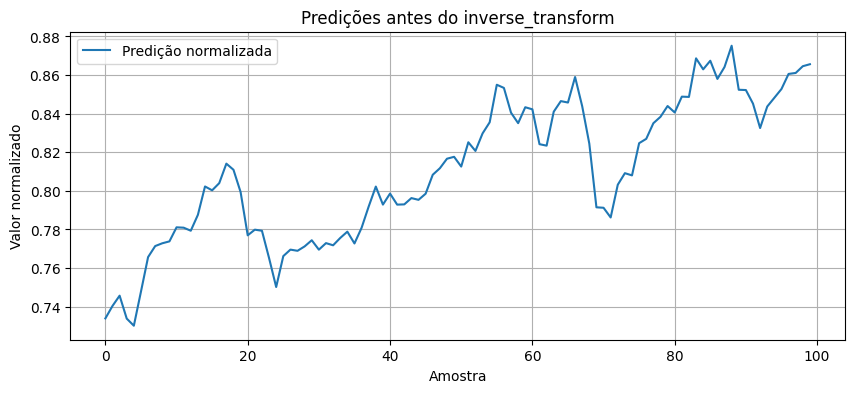

Predição (normalizada) - min: 0.7301, max: 0.9897, média: 0.8765


In [ ]:
# Diagnostic: distribution of normalized predictions
plt.figure(figsize=(10, 4))
# Plotting the first 100 predictions to check for signal variance
plt.plot(preds[:100], label='Normalized Prediction')
plt.title('Predictions Before Inverse Transform')
plt.xlabel('Sample')
plt.ylabel('Normalized Value')
plt.grid()
plt.legend()
plt.show()

# Print summary statistics for the normalized output
print(f"Prediction (normalized) - min: {preds.min():.4f}, max: {preds.max():.4f}, mean: {preds.mean():.4f}")

Finally, We Plot a future prediction of ten days based on previous history.

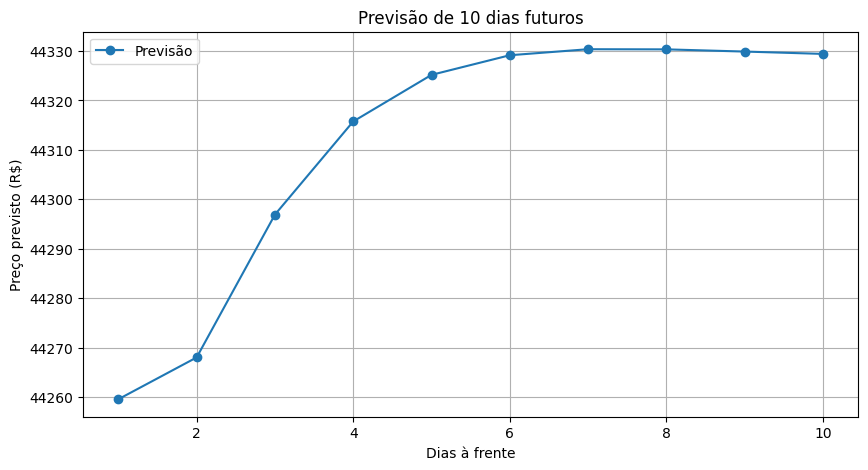

Dia +1: R$ 44259.60
Dia +2: R$ 44268.04
Dia +3: R$ 44296.92
Dia +4: R$ 44315.75
Dia +5: R$ 44325.17
Dia +6: R$ 44329.14
Dia +7: R$ 44330.35
Dia +8: R$ 44330.32
Dia +9: R$ 44329.88
Dia +10: R$ 44329.41


In [ ]:
# Multi-day forecasting (e.g., 7-10 days ahead)
model.eval()
n_future = 10  # Number of days to predict

# Use the most recent available data
last_sequence = data[-seq_len:].values
last_scaled = scaler.transform(last_sequence)
future_preds = []

# Prepare the initial input tensor
current_input = torch.tensor(last_scaled, dtype=torch.float32).unsqueeze(0).to(device)

for _ in range(n_future):
    with torch.no_grad():
        next_pred = model(current_input)

    # Extract the predicted value (normalized)
    pred_val = next_pred.cpu().numpy()[0, 0]
    future_preds.append(pred_val)

    # Create the next time step entry
    # Note: We keep the other features constant or use the last known values
    next_step = np.zeros((1, scaler.n_features_in_))
    next_step[0, 0] = pred_val
    next_step[0, 1:] = current_input[0, -1, 1:].cpu().numpy()

    # Update the sliding window: remove the oldest step and add the new prediction
    next_sequence = torch.cat([
        current_input[:, 1:, :],
        torch.tensor(next_step, dtype=torch.float32).unsqueeze(0).to(device)
    ], dim=1)

    current_input = next_sequence

# Inverse transform the results to original currency/units
future_scaled_full = np.zeros((n_future, scaler.n_features_in_))
future_scaled_full[:, 0] = future_preds
future_prices = scaler.inverse_transform(future_scaled_full)[:, 0]

# Visualization
plt.figure(figsize=(10,5))
plt.plot(range(1, n_future + 1), future_prices, marker='o', label='Forecast')
plt.title('10-Day Future Forecast')
plt.xlabel('Days Ahead')
plt.ylabel('Predicted Price (R$)')
plt.grid()
plt.legend()
plt.show()

# Display the values in the console
for i, p in enumerate(future_prices):
    print(f"Day +{i+1}: R$ {p:.2f}")